In [ ]:
import cv2, sys
import numpy as np
import matplotlib.pyplot as plt
import os, glob
import micasense.capture as capture
import micasense.imageutils as imageutils
import micasense.plotutils as plotutils
sys.path.append("d:/USDA-NIFA/Code")
os.chdir("d:/USDA-NIFA/Code")
os.getcwd()

'c:\\Users\\vince\\Desktop\\USDA-NIFA\\Code'

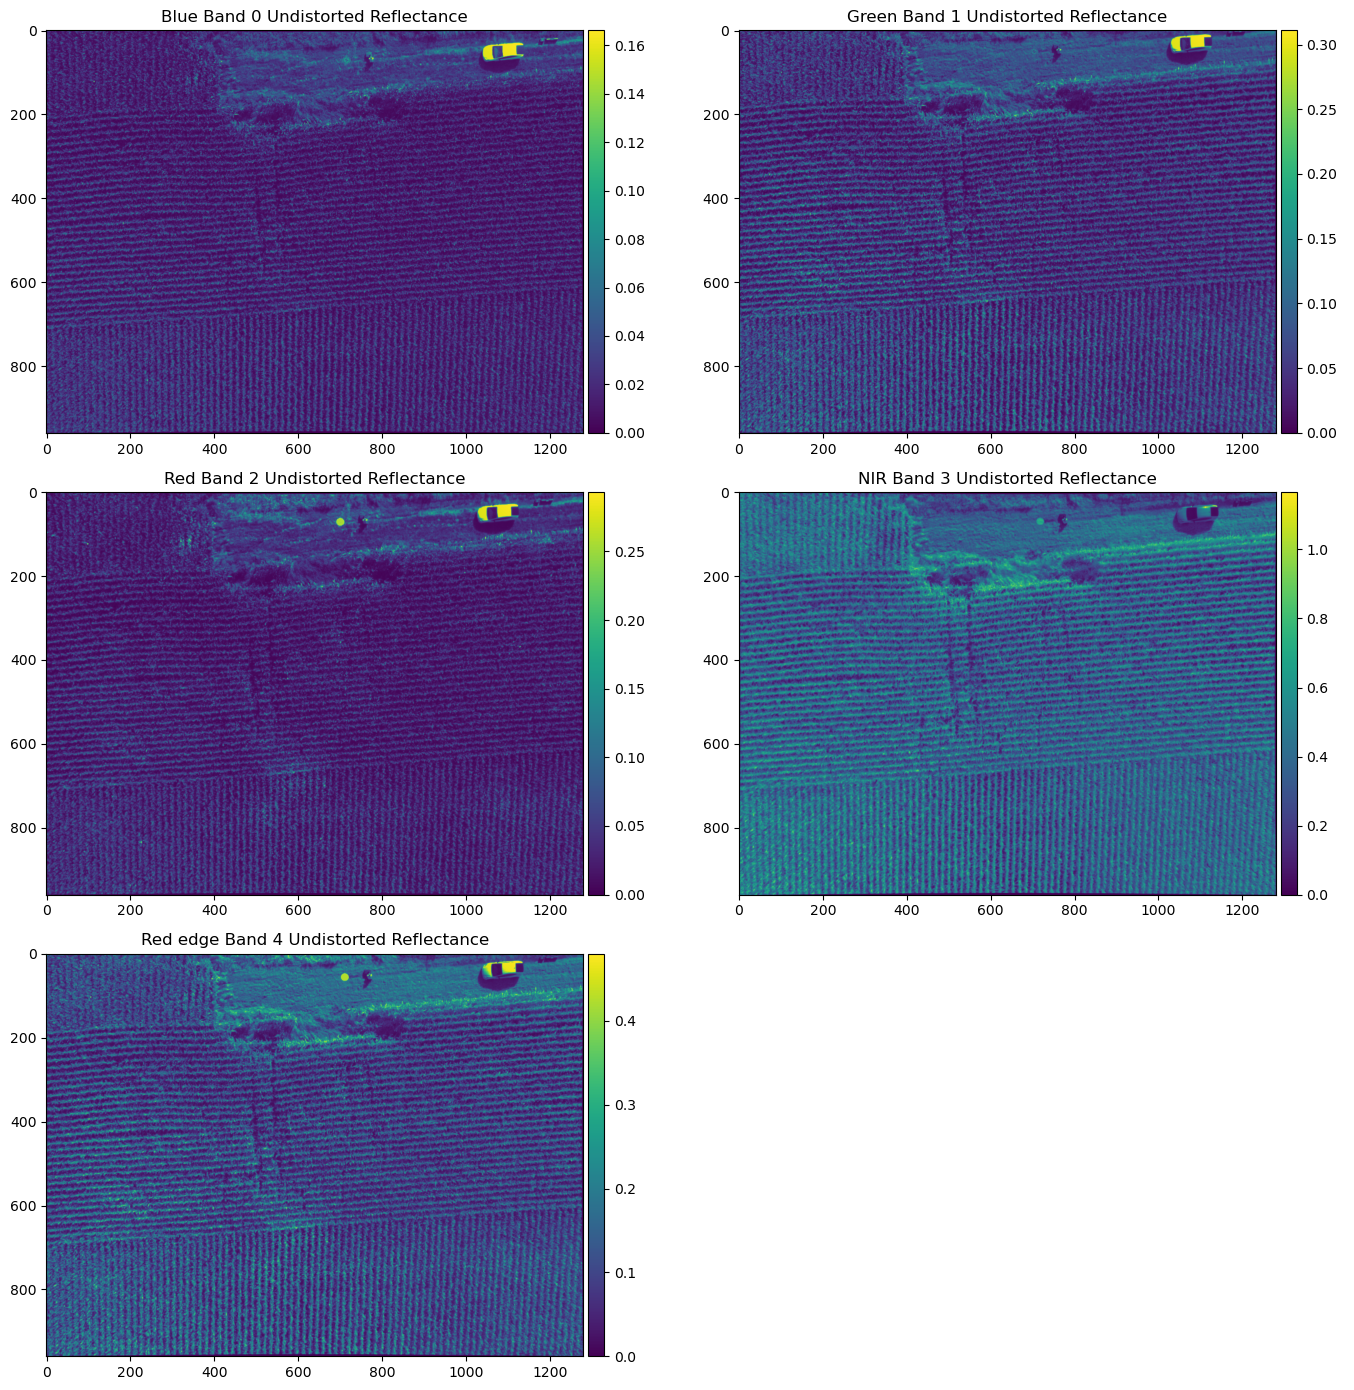

In [3]:
panelNames = None

# This is an Altum image with RigRelatives and a thermal band

imagePath = "./B1/Images"
panelPath = "./B1/Panel"

# these will return lists of image paths as strings 
imageNames = list(glob.glob(os.path.join(imagePath, 'IMG_0007_*.tif')))

panelNames = list(glob.glob(os.path.join(panelPath, 'IMG_0000_*.tif')))
if panelNames is not None:
    panelCap = capture.Capture.from_filelist(panelNames)
else:
    panelCap = None

capture = capture.Capture.from_filelist(imageNames)

for img in capture.images:
    if img.rig_relatives is None:
        raise ValueError("Images must have RigRelatives tags set which requires updated firmware and calibration. See the links in text above")

if panelCap is not None:
    if panelCap.panel_albedo() is not None:
        panel_reflectance_by_band = panelCap.panel_albedo()
    else:
        panel_reflectance_by_band = [0.49, 0.49, 0.49, 0.49, 0.49] #RedEdge band_index order
    panel_irradiance = panelCap.panel_irradiance(panel_reflectance_by_band)    
    img_type = "reflectance"
    capture.plot_undistorted_reflectance(panel_irradiance)
else:
    img_type = "radiance"
    capture.plot_undistorted_radiance()    

In [5]:
capture

In [4]:
reference_band = 2  # use the Red band as the reference
warp_mode = cv2.MOTION_HOMOGRAPHY
warp_matrices = capture.get_warp_matrices(ref_index=reference_band)

cropped_dimensions,edges = imageutils.find_crop_bounds(capture,warp_matrices,reference_band=reference_band)
im_aligned = imageutils.aligned_capture(capture, warp_matrices, warp_mode, cropped_dimensions, reference_band, img_type=img_type)

print(im_aligned.shape)

print("warp_matrices={}".format(warp_matrices))

(924, 1253, 5)
warp_matrices=[array([[ 1.00374874e+00, -1.18617900e-03,  1.54652055e+01],
       [ 2.91800717e-03,  1.00065347e+00, -3.34010013e+00],
       [ 5.05108001e-06, -1.17054370e-06,  1.00000000e+00]]), array([[ 1.00272694e+00, -4.02104034e-03,  1.86810190e+00],
       [ 4.95498868e-03,  1.00014024e+00, -2.52352387e+01],
       [ 3.64541588e-06, -1.24921509e-06,  1.00000000e+00]]), array([[ 1.00000000e+00,  1.75442638e-21, -1.36935086e-13],
       [ 1.11175832e-19,  1.00000000e+00, -1.13686838e-13],
       [ 1.33904085e-22, -7.02240450e-23,  1.00000000e+00]]), array([[ 1.01063424e+00, -3.04902488e-03,  1.59968790e+01],
       [ 6.60865510e-03,  1.00763453e+00, -7.07240739e+00],
       [ 6.26934142e-06,  7.29038428e-07,  1.00000000e+00]]), array([[ 1.00814693e+00, -7.50638126e-03,  8.43667308e+00],
       [ 8.77657981e-03,  1.00647307e+00, -2.24858761e+01],
       [ 3.67836026e-06, -7.73740867e-07,  1.00000000e+00]])]


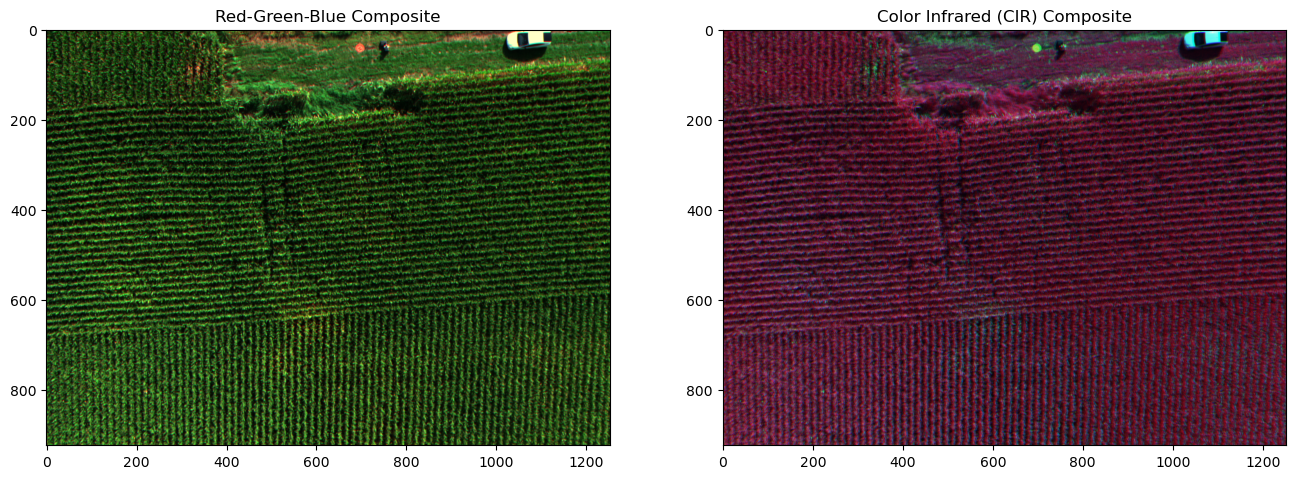

In [11]:
# figsize=(30,23) # use this size for full-image-resolution display
figsize=(16,13)   # use this size for export-sized display

rgb_band_indices = [2,1,0]
cir_band_indices = [3,2,1]

# Create an empty normalized stack for viewing
im_display = np.zeros((im_aligned.shape[0],im_aligned.shape[1],im_aligned.shape[2]), dtype=np.float32 )

im_min = np.percentile(im_aligned[:,:,0:2].flatten(),  0.1)  # modify with these percentilse to adjust contrast
im_max = np.percentile(im_aligned[:,:,0:2].flatten(), 99.9)  # for many images, 0.5 and 99.5 are good values

for i in range(0,im_aligned.shape[2]):
    if img_type == 'reflectance':
        # for reflectance images we maintain white-balance by applying the same display scaling to all bands
        im_display[:,:,i] =  imageutils.normalize(im_aligned[:,:,i], im_min, im_max)
    elif img_type == 'radiance':
        # for radiance images we do an auto white balance since we don't know the input light spectrum by
        # stretching each display band histogram to it's own min and max
        im_display[:,:,i] =  imageutils.normalize(im_aligned[:,:,i])

rgb = im_display[:,:,rgb_band_indices]
# for cir false color imagery, we normalize the NIR,R,G bands within themselves, which provides
# the classical CIR rendering where plants are red and soil takes on a blue tint
for i in cir_band_indices:
    im_display[:,:,i] =  imageutils.normalize(im_aligned[:,:,i])

cir = im_display[:,:,cir_band_indices]
fig, axes = plt.subplots(1, 2, figsize=figsize)
axes[0].set_title("Red-Green-Blue Composite")
axes[0].imshow(rgb)
axes[1].set_title("Color Infrared (CIR) Composite")
axes[1].imshow(cir)
plt.show()